# Детекция номеров на городских изображениях

Этот ноутбук:

- готовит датасет **SVHN Full Numbers** из архива;
- используя **Roboflow NumberDetection** делает короткое предобучение;
- дообучает детектор на **SVHN**;
- строит визуализации датасета;
- строит графики обучения и валидации;
- считает **IoU, Precision, Recall, mAP50, mAP50-95** на тесте;
- запускает инференс на ваших собственных фотографиях улицы.

In [1]:
%pip install ultralytics roboflow h5py pyyaml opencv-python pillow tqdm pandas matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import os
import io
import gc
import json
import math
import time
import yaml
import h5py
import shutil
import random
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO


In [3]:
@dataclass
class CFG:
    seed: int = 42
    base_model: str = "yolo11n.pt"
    imgsz: int = 640
    batch: int = 96
    workers: int = 12
    device: int | str = 0
    pretrain_epochs: int = 6
    finetune_epochs: int = 18
    patience: int = 8
    conf_eval: float = 0.25
    iou_eval: float = 0.50
    val_size: float = 0.10
    debug_fraction: float = 1.0
    skip_existing_runs: bool = True

    project_dir: Path = Path.cwd() / "street_number_detector"
    raw_dir: Path = project_dir / "data" / "raw"
    processed_dir: Path = project_dir / "data" / "processed"
    models_dir: Path = project_dir / "models"
    runs_dir: Path = project_dir / "runs"
    inference_dir: Path = project_dir / "inference"
    street_photos_dir: Path = project_dir / "data" / "street_photos"

    svhn_train_url: str = "https://ufldl.stanford.edu/housenumbers/train.tar.gz"
    svhn_test_url: str = "https://ufldl.stanford.edu/housenumbers/test.tar.gz"

    roboflow_api_key: str | None = os.getenv("ROBOFLOW_API_KEY", None)
    roboflow_workspace: str = "university-of-toronto-xho85"
    roboflow_project: str = "numberdetection-eppfj"
    roboflow_version: int = 2

CFG = CFG()
CFG.project_dir.mkdir(parents=True, exist_ok=True)
CFG.raw_dir.mkdir(parents=True, exist_ok=True)
CFG.processed_dir.mkdir(parents=True, exist_ok=True)
CFG.models_dir.mkdir(parents=True, exist_ok=True)
CFG.runs_dir.mkdir(parents=True, exist_ok=True)
CFG.inference_dir.mkdir(parents=True, exist_ok=True)
CFG.street_photos_dir.mkdir(parents=True, exist_ok=True)

SVHN_YAML = CFG.processed_dir / "svhn_sequence.yaml"
NUMBERDETECTION_DIR = CFG.raw_dir / "numberdetection"
NUMBERDETECTION_YAML = NUMBERDETECTION_DIR / "data.yaml"

print(CFG)


CFG(seed=42, base_model='yolo11n.pt', imgsz=640, batch=96, workers=12, device=0, pretrain_epochs=6, finetune_epochs=18, patience=8, conf_eval=0.25, iou_eval=0.5, val_size=0.1, debug_fraction=1.0, skip_existing_runs=True, project_dir=PosixPath('/home/user/street_number_detector'), raw_dir=PosixPath('/home/user/street_number_detector/data/raw'), processed_dir=PosixPath('/home/user/street_number_detector/data/processed'), models_dir=PosixPath('/home/user/street_number_detector/models'), runs_dir=PosixPath('/home/user/street_number_detector/runs'), inference_dir=PosixPath('/home/user/street_number_detector/inference'), street_photos_dir=PosixPath('/home/user/street_number_detector/data/street_photos'), svhn_train_url='https://ufldl.stanford.edu/housenumbers/train.tar.gz', svhn_test_url='https://ufldl.stanford.edu/housenumbers/test.tar.gz', roboflow_api_key=None, roboflow_workspace='university-of-toronto-xho85', roboflow_project='numberdetection-eppfj', roboflow_version=2)


In [4]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(CFG.seed)


## Вспомогательные функции


In [5]:
def download_file(url: str, dst: Path) -> Path:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        print(f"Уже скачано: {dst}")
        return dst
    print(f"Скачивание: {url}")
    urllib.request.urlretrieve(url, dst)
    return dst


def extract_tar_gz(archive_path: Path, dst_dir: Path) -> Path:
    import tarfile

    if dst_dir.exists() and any(dst_dir.iterdir()):
        print(f"Уже распаковано: {dst_dir}")
        return dst_dir

    dst_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(dst_dir.parent)
    return dst_dir


def load_rgb(path: str | Path) -> np.ndarray:
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def read_yolo_label(label_path: str | Path, img_w: int, img_h: int) -> list[list[float]]:
    label_path = Path(label_path)
    if not label_path.exists():
        return []

    boxes = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            cls_id, xc, yc, w, h = map(float, line.strip().split())
            x1 = (xc - w / 2) * img_w
            y1 = (yc - h / 2) * img_h
            x2 = (xc + w / 2) * img_w
            y2 = (yc + h / 2) * img_h
            boxes.append([int(cls_id), x1, y1, x2, y2])
    return boxes


def draw_boxes(image: np.ndarray, boxes: list[list[float]], color=(255, 0, 0), lw: int = 2) -> np.ndarray:
    out = image.copy()
    for box in boxes:
        _, x1, y1, x2, y2 = box
        cv2.rectangle(out, (int(x1), int(y1)), (int(x2), int(y2)), color, lw)
    return out


def show_random_yolo_samples(images_dir: Path, labels_dir: Path, n: int = 9, cols: int = 3, figsize=(14, 12)) -> None:
    image_paths = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
    if len(image_paths) == 0:
        print(f"Нет изображений в {images_dir}")
        return

    n = min(n, len(image_paths))
    chosen = random.sample(image_paths, n)
    rows = math.ceil(n / cols)

    plt.figure(figsize=figsize)
    for i, img_path in enumerate(chosen, start=1):
        img = load_rgb(img_path)
        h, w = img.shape[:2]
        label_path = labels_dir / f"{img_path.stem}.txt"
        boxes = read_yolo_label(label_path, w, h)
        vis = draw_boxes(img, boxes)

        plt.subplot(rows, cols, i)
        plt.imshow(vis)
        plt.title(img_path.name, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def yolo_box_to_xyxy(xc: float, yc: float, w: float, h: float, img_w: int, img_h: int) -> list[float]:
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return [x1, y1, x2, y2]


def xyxy_to_yolo(x1: float, y1: float, x2: float, y2: float, img_w: int, img_h: int) -> list[float]:
    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))
    w = max(1e-6, x2 - x1)
    h = max(1e-6, y2 - y1)
    xc = x1 + w / 2
    yc = y1 + h / 2
    return [xc / img_w, yc / img_h, w / img_w, h / img_h]


def box_iou_xyxy(a: list[float], b: list[float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - inter
    if union <= 0:
        return 0.0
    return inter / union


def plot_results_csv(results_csv: Path, title: str) -> None:
    if not results_csv.exists():
        print(f"Не найден файл {results_csv}")
        return

    df = pd.read_csv(results_csv)
    cols = [c for c in df.columns if "epoch" not in c.lower()]

    train_loss_cols = [c for c in cols if "train" in c.lower() and "loss" in c.lower()]
    val_loss_cols = [c for c in cols if "val" in c.lower() and "loss" in c.lower()]
    metric_cols = [c for c in cols if any(k in c.lower() for k in ["precision", "recall", "map"])]

    plt.figure(figsize=(14, 5))
    for c in train_loss_cols + val_loss_cols:
        plt.plot(df.index + 1, df[c], label=c)
    plt.title(f"{title}: loss")
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if metric_cols:
        plt.figure(figsize=(14, 5))
        for c in metric_cols:
            plt.plot(df.index + 1, df[c], label=c)
        plt.title(f"{title}: quality metrics")
        plt.xlabel("epoch")
        plt.ylabel("value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


def build_dataset_summary(images_dir: Path, labels_dir: Path) -> pd.DataFrame:
    rows = []
    image_paths = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
    for img_path in tqdm(image_paths):
        with Image.open(img_path) as img:
            w, h = img.size
        label_path = labels_dir / f"{img_path.stem}.txt"
        boxes = read_yolo_label(label_path, w, h)
        for box in boxes:
            _, x1, y1, x2, y2 = box
            bw = x2 - x1
            bh = y2 - y1
            rows.append(
                {
                    "image": img_path.name,
                    "img_w": w,
                    "img_h": h,
                    "bbox_w": bw,
                    "bbox_h": bh,
                    "bbox_area": bw * bh,
                    "bbox_area_ratio": (bw * bh) / (w * h),
                    "aspect_ratio": bw / max(1e-6, bh),
                }
            )
    return pd.DataFrame(rows)


## Подготовка официального SVHN Full Numbers → YOLO

Здесь мы:

- скачиваем `train.tar.gz` и `test.tar.gz` с официального сайта;
- читаем `digitStruct.mat`;
- объединяем боксы отдельных цифр в **один бокс на весь номер**;
- делаем `train/val/test` в формате YOLO.


In [6]:
def _resolve_svhn_scalar(h5_file: h5py.File, value) -> float:
    try:
        return float(np.asarray(h5_file[value][()]).squeeze())
    except Exception:
        return float(np.asarray(value).squeeze())


def _resolve_svhn_string(h5_file: h5py.File, ref) -> str:
    arr = h5_file[ref][()]
    arr = np.asarray(arr).astype(np.uint8).squeeze()
    if arr.ndim == 0:
        arr = np.array([arr])
    return "".join(chr(int(x)) for x in arr)


def read_svhn_digitstruct(mat_path: Path) -> list[dict]:
    records = []
    with h5py.File(mat_path, "r") as h5_file:
        names = h5_file["digitStruct"]["name"]
        bboxes = h5_file["digitStruct"]["bbox"]

        for idx in tqdm(range(len(names)), desc=f"Чтение {mat_path.parent.name}"):
            name_ref = names[idx][0]
            bbox_ref = bboxes[idx][0]

            image_name = _resolve_svhn_string(h5_file, name_ref)
            bbox_group = h5_file[bbox_ref]

            sample = {"image_name": image_name}
            for key in ["label", "left", "top", "width", "height"]:
                ds = bbox_group[key]
                values = []
                for j in range(ds.shape[0]):
                    values.append(_resolve_svhn_scalar(h5_file, ds[j][0]))
                sample[key] = values

            records.append(sample)
    return records


def svhn_sequence_box(record: dict, img_w: int, img_h: int) -> list[float]:
    left = np.array(record["left"], dtype=float)
    top = np.array(record["top"], dtype=float)
    width = np.array(record["width"], dtype=float)
    height = np.array(record["height"], dtype=float)

    x1 = float(left.min())
    y1 = float(top.min())
    x2 = float((left + width).max())
    y2 = float((top + height).max())

    x1 = max(0.0, min(x1, img_w - 1))
    y1 = max(0.0, min(y1, img_h - 1))
    x2 = max(0.0, min(x2, img_w - 1))
    y2 = max(0.0, min(y2, img_h - 1))

    return [x1, y1, x2, y2]


def make_yolo_dirs(root: Path) -> None:
    for split in ["train", "val", "test"]:
        (root / "images" / split).mkdir(parents=True, exist_ok=True)
        (root / "labels" / split).mkdir(parents=True, exist_ok=True)


def prepare_svhn_sequence_yolo(cfg: CFG) -> tuple[Path, pd.DataFrame]:
    train_archive = download_file(cfg.svhn_train_url, cfg.raw_dir / "train.tar.gz")
    test_archive = download_file(cfg.svhn_test_url, cfg.raw_dir / "test.tar.gz")

    train_dir = cfg.raw_dir / "train"
    test_dir = cfg.raw_dir / "test"

    extract_tar_gz(train_archive, train_dir)
    extract_tar_gz(test_archive, test_dir)

    processed_root = cfg.processed_dir / "svhn_sequence"
    make_yolo_dirs(processed_root)

    manifest_path = cfg.processed_dir / "svhn_sequence_manifest.csv"
    if manifest_path.exists() and SVHN_YAML.exists():
        print("Готовый SVHN YOLO уже найден.")
        manifest = pd.read_csv(manifest_path)
        return SVHN_YAML, manifest

    train_records = read_svhn_digitstruct(train_dir / "digitStruct.mat")
    test_records = read_svhn_digitstruct(test_dir / "digitStruct.mat")

    if cfg.debug_fraction < 1.0:
        rng = np.random.default_rng(cfg.seed)
        train_keep = int(len(train_records) * cfg.debug_fraction)
        test_keep = int(len(test_records) * cfg.debug_fraction)
        train_records = list(rng.choice(train_records, size=train_keep, replace=False))
        test_records = list(rng.choice(test_records, size=test_keep, replace=False))

    train_ids = list(range(len(train_records)))
    train_idx, val_idx = train_test_split(
        train_ids,
        test_size=cfg.val_size,
        random_state=cfg.seed,
        shuffle=True,
    )

    split_map = {}
    for i in train_idx:
        split_map[("train", i)] = "train"
    for i in val_idx:
        split_map[("train", i)] = "val"
    for i in range(len(test_records)):
        split_map[("test", i)] = "test"

    manifest_rows = []

    for split_name, records, src_dir in [
        ("train", train_records, train_dir),
        ("test", test_records, test_dir),
    ]:
        iterator = enumerate(records)
        iterator = tqdm(iterator, total=len(records), desc=f"Конвертация {split_name}")
        for idx, record in iterator:
            dst_split = split_map[(split_name, idx)]

            src_img = src_dir / record["image_name"]
            dst_img = processed_root / "images" / dst_split / record["image_name"]
            dst_lbl = processed_root / "labels" / dst_split / f"{Path(record['image_name']).stem}.txt"

            with Image.open(src_img) as img:
                img_w, img_h = img.size

            x1, y1, x2, y2 = svhn_sequence_box(record, img_w, img_h)
            xc, yc, bw, bh = xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h)

            shutil.copy2(src_img, dst_img)
            with open(dst_lbl, "w", encoding="utf-8") as f:
                f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

            manifest_rows.append(
                {
                    "source_split": split_name,
                    "yolo_split": dst_split,
                    "image_name": record["image_name"],
                    "img_w": img_w,
                    "img_h": img_h,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "digits_count": len(record["label"]),
                }
            )

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(manifest_path, index=False)

    yaml_data = {
        "path": str(processed_root.resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {0: "number"},
        "nc": 1,
    }
    with open(SVHN_YAML, "w", encoding="utf-8") as f:
        yaml.safe_dump(yaml_data, f, sort_keys=False, allow_unicode=True)

    return SVHN_YAML, manifest


SVHN_YAML, svhn_manifest = prepare_svhn_sequence_yolo(CFG)
print(SVHN_YAML)
svhn_manifest.head()


Уже скачано: /home/user/street_number_detector/data/raw/train.tar.gz
Уже скачано: /home/user/street_number_detector/data/raw/test.tar.gz
Уже распаковано: /home/user/street_number_detector/data/raw/train
Уже распаковано: /home/user/street_number_detector/data/raw/test
Готовый SVHN YOLO уже найден.
/home/user/street_number_detector/data/processed/svhn_sequence.yaml


,source_split,yolo_split,image_name,img_w,img_h,x1,y1,x2,y2,digits_count
0,train,train,1.png,741,350,246.0,77.0,419.0,300.0,2
1,train,train,2.png,199,83,77.0,25.0,124.0,61.0,2
2,train,train,3.png,52,23,17.0,5.0,34.0,20.0,2
3,train,train,4.png,161,79,57.0,13.0,85.0,47.0,2
4,train,train,5.png,140,68,52.0,7.0,89.0,56.0,2


## Визуализация SVHN


,yolo_split,images
0,test,13068
1,train,30061
2,val,3341


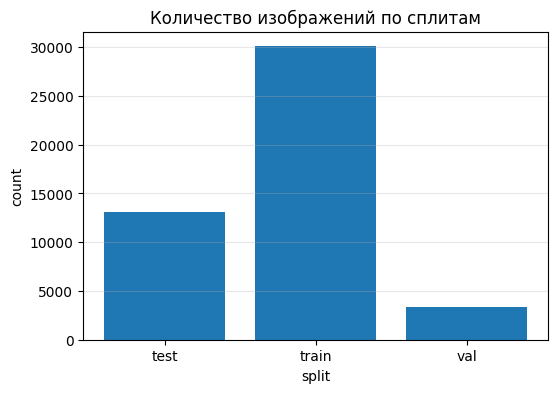

In [7]:
svhn_root = CFG.processed_dir / "svhn_sequence"

split_counts = (
    svhn_manifest.groupby("yolo_split")["image_name"]
    .count()
    .rename("images")
    .reset_index()
)

display(split_counts)

plt.figure(figsize=(6, 4))
plt.bar(split_counts["yolo_split"], split_counts["images"])
plt.title("Количество изображений по сплитам")
plt.xlabel("split")
plt.ylabel("count")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


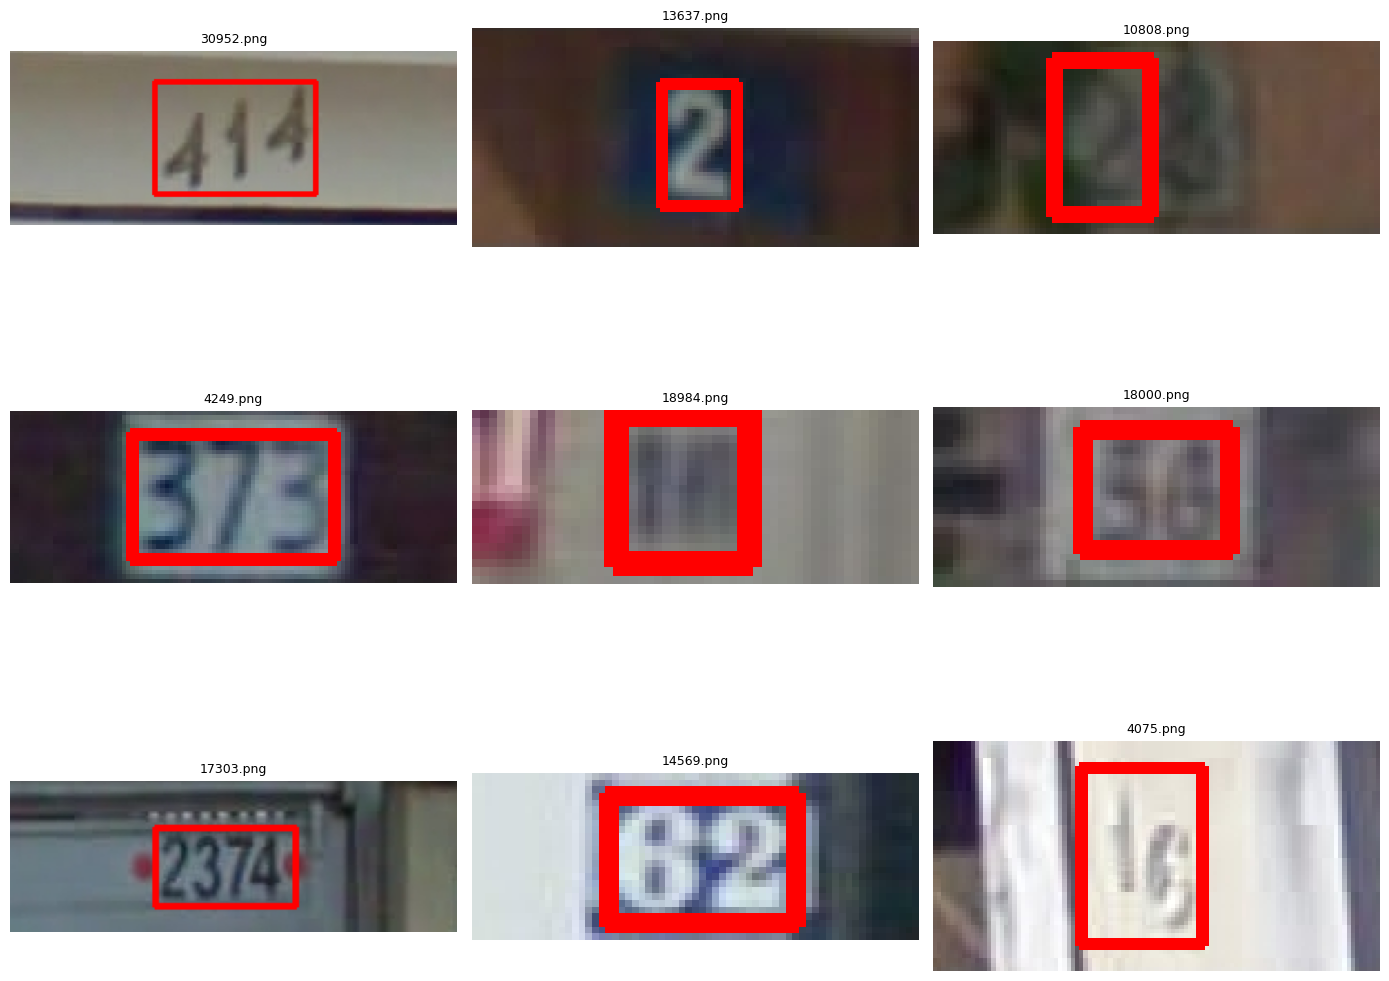

In [8]:
show_random_yolo_samples(
    svhn_root / "images" / "train",
    svhn_root / "labels" / "train",
    n=9,
    cols=3,
    figsize=(14, 12),
)


In [9]:
svhn_stats = build_dataset_summary(
    svhn_root / "images" / "train",
    svhn_root / "labels" / "train",
)
svhn_stats.head()


  0%|          | 0/30061 [00:00<?, ?it/s]

,image,img_w,img_h,bbox_w,bbox_h,bbox_area,bbox_area_ratio,aspect_ratio
0,1.png,741,350,172.999788,223.000050,38578.961374,0.148753,0.775784
1,10.png,74,37,23.000014,29.000008,667.000590,0.243609,0.793104
2,1000.png,44,21,10.000012,18.000003,180.000246,0.194805,0.555556
3,10000.png,137,62,43.000053,31.999998,1376.001610,0.161997,1.343752
4,10001.png,66,33,11.999988,21.000012,251.999892,0.115702,0.571428


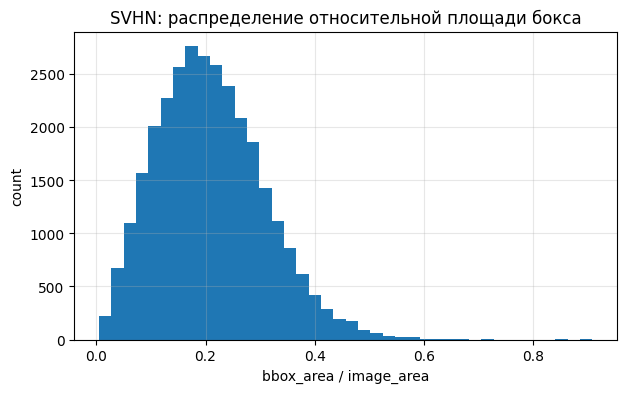

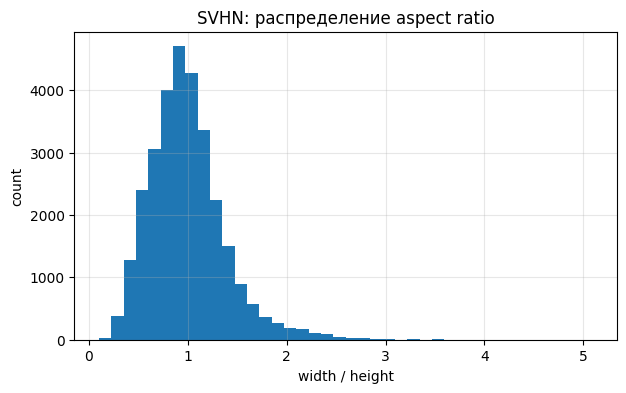

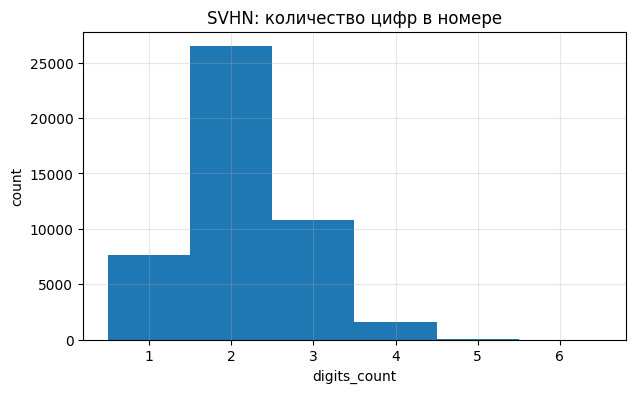

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(svhn_stats["bbox_area_ratio"], bins=40)
plt.title("SVHN: распределение относительной площади бокса")
plt.xlabel("bbox_area / image_area")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(svhn_stats["aspect_ratio"], bins=40)
plt.title("SVHN: распределение aspect ratio")
plt.xlabel("width / height")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(svhn_manifest["digits_count"], bins=np.arange(1, svhn_manifest["digits_count"].max() + 2) - 0.5)
plt.title("SVHN: количество цифр в номере")
plt.xlabel("digits_count")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()


# Загрузка NumberDetection из Roboflow

Этот этап улучшает старт модели перед дообучением на SVHN.  

In [11]:
def try_download_numberdetection(cfg: CFG) -> Path | None:
    if NUMBERDETECTION_YAML.exists():
        print(f"Найден локальный датасет: {NUMBERDETECTION_YAML}")
        return NUMBERDETECTION_YAML

    try:
        from roboflow import Roboflow

        rf = Roboflow(api_key=cfg.roboflow_api_key)
        project = rf.workspace(cfg.roboflow_workspace).project(cfg.roboflow_project)
        version = project.version(cfg.roboflow_version)
        dataset = version.download("yolov8", location=str(NUMBERDETECTION_DIR))
        yaml_path = Path(dataset.location) / "data.yaml"
        if yaml_path.exists():
            print(f"Успешно скачано: {yaml_path}")
            return yaml_path
    except Exception as e:
        print(f"Не удалось скачать NumberDetection автоматически: {e}")

    return None


numberdetection_yaml = try_download_numberdetection(CFG)
print(numberdetection_yaml)


Найден локальный датасет: /home/user/street_number_detector/data/raw/numberdetection/data.yaml
/home/user/street_number_detector/data/raw/numberdetection/data.yaml


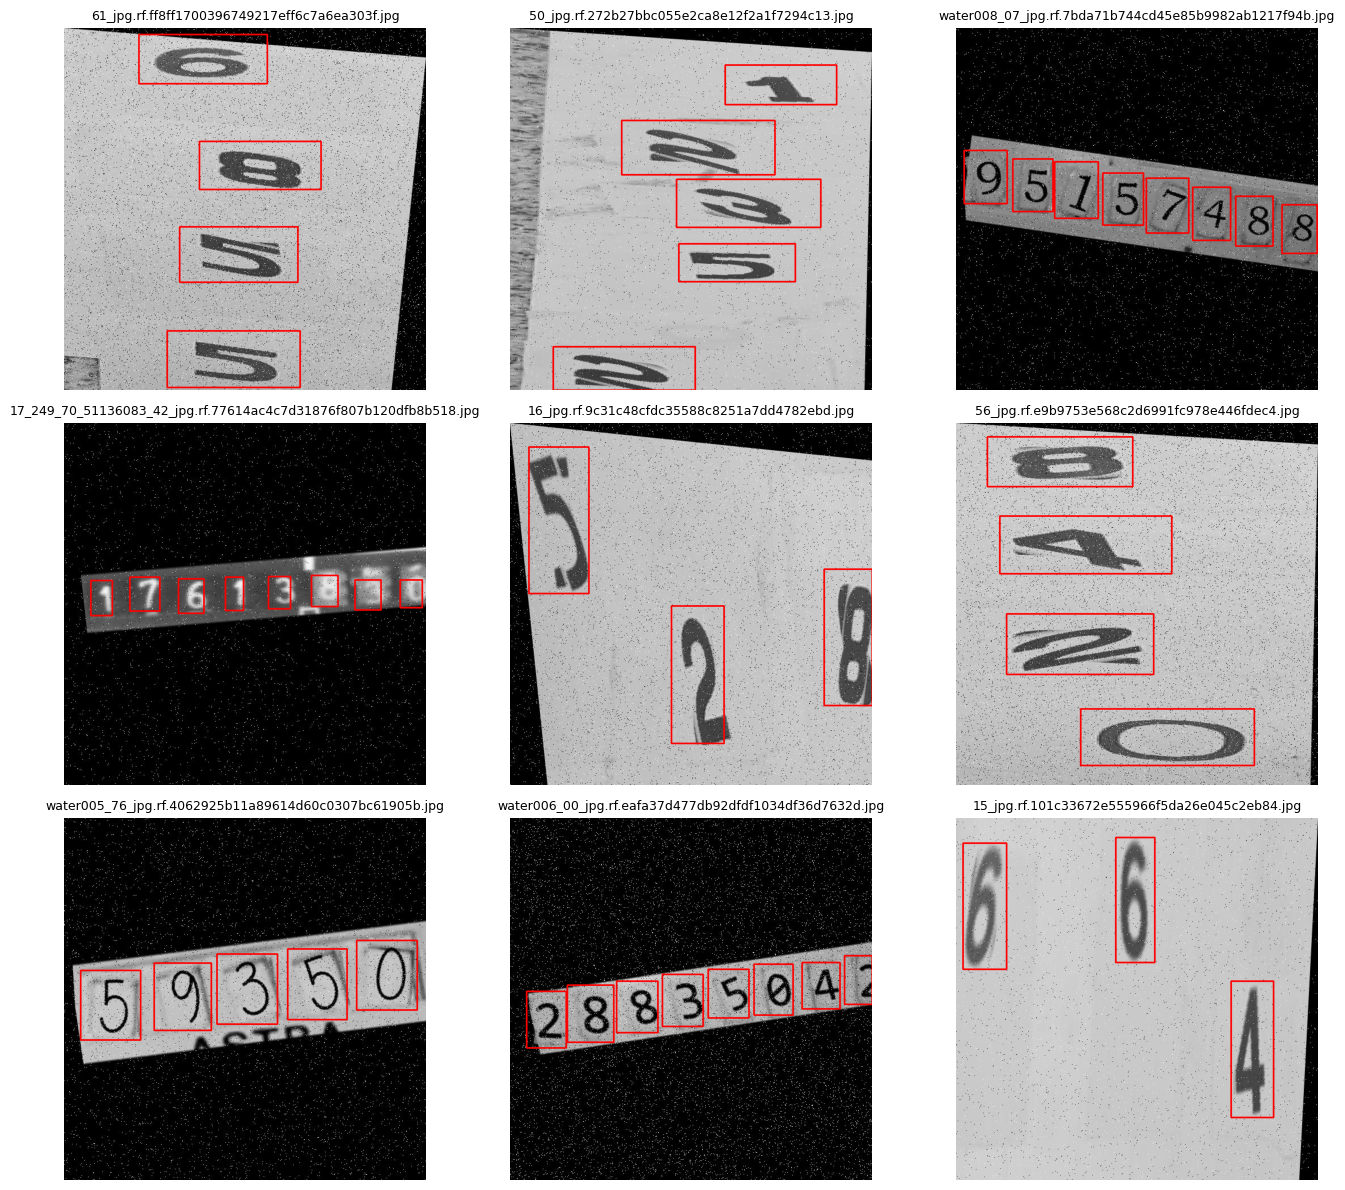

In [12]:
    nd_root = Path(numberdetection_yaml).parent
    show_random_yolo_samples(
        nd_root / "train" / "images",
        nd_root / "train" / "labels",
        n=9,
        cols=3,
        figsize=(14, 12),
    )


## Обучение

Схема по умолчанию такая:

1. **Stage 1** — короткое предобучение на `NumberDetection`, если он доступен.
2. **Stage 2** — основное дообучение на `SVHN`.

По умолчанию используется `yolo11n.pt`: это маленькая и быстрая модель, у которой хорошее соотношение скорости и качества для такого задания.


In [13]:
def train_yolo_if_needed(
    model_weights: str | Path,
    data_yaml: str | Path,
    run_name: str,
    epochs: int,
    cfg: CFG,
    extra_train_args: dict | None = None,
) -> Path:
    run_dir = cfg.runs_dir / run_name
    best_path = run_dir / "weights" / "best.pt"

    if cfg.skip_existing_runs and best_path.exists():
        print(f"Пропускаю обучение, уже есть {best_path}")
        return best_path

    train_args = dict(
        data=str(data_yaml),
        epochs=epochs,
        imgsz=cfg.imgsz,
        batch=cfg.batch,
        device=cfg.device,
        workers=cfg.workers,
        project=str(cfg.runs_dir),
        name=run_name,
        exist_ok=True,
        amp=True,
        cache=True,
        patience=cfg.patience,
        plots=True,
        save=True,
        cos_lr=True,
        close_mosaic=3,
        optimizer="auto",
        seed=cfg.seed,
        degrees=0.0,
        translate=0.05,
        scale=0.25,
        shear=0.0,
        perspective=0.0,
        fliplr=0.0,
        flipud=0.0,
        mosaic=0.5,
        mixup=0.0,
        hsv_h=0.015,
        hsv_s=0.4,
        hsv_v=0.2,
    )

    if extra_train_args:
        train_args.update(extra_train_args)

    model = YOLO(str(model_weights))
    model.train(**train_args)

    best_path = run_dir / "weights" / "best.pt"
    last_path = run_dir / "weights" / "last.pt"

    if best_path.exists():
        shutil.copy2(best_path, cfg.models_dir / f"{run_name}_best.pt")
    if last_path.exists():
        shutil.copy2(last_path, cfg.models_dir / f"{run_name}_last.pt")

    gc.collect()
    return best_path


In [14]:
stage1_weights = CFG.base_model

    stage1_weights = train_yolo_if_needed(
        model_weights=CFG.base_model,
        data_yaml=numberdetection_yaml,
        run_name="stage1_numberdetection",
        epochs=CFG.pretrain_epochs,
        cfg=CFG,
    )
    print(f"Stage 1 best weights: {stage1_weights}")


Пропускаю обучение, уже есть /home/user/street_number_detector/runs/stage1_numberdetection/weights/best.pt
Stage 1 best weights: /home/user/street_number_detector/runs/stage1_numberdetection/weights/best.pt


In [15]:
stage2_weights = train_yolo_if_needed(
    model_weights=stage1_weights,
    data_yaml=SVHN_YAML,
    run_name="stage2_svhn_finetune",
    epochs=CFG.finetune_epochs,
    cfg=CFG,
)

print(f"Stage 2 best weights: {stage2_weights}")


Пропускаю обучение, уже есть /home/user/street_number_detector/runs/stage2_svhn_finetune/weights/best.pt
Stage 2 best weights: /home/user/street_number_detector/runs/stage2_svhn_finetune/weights/best.pt


## Графики обучения и валидации


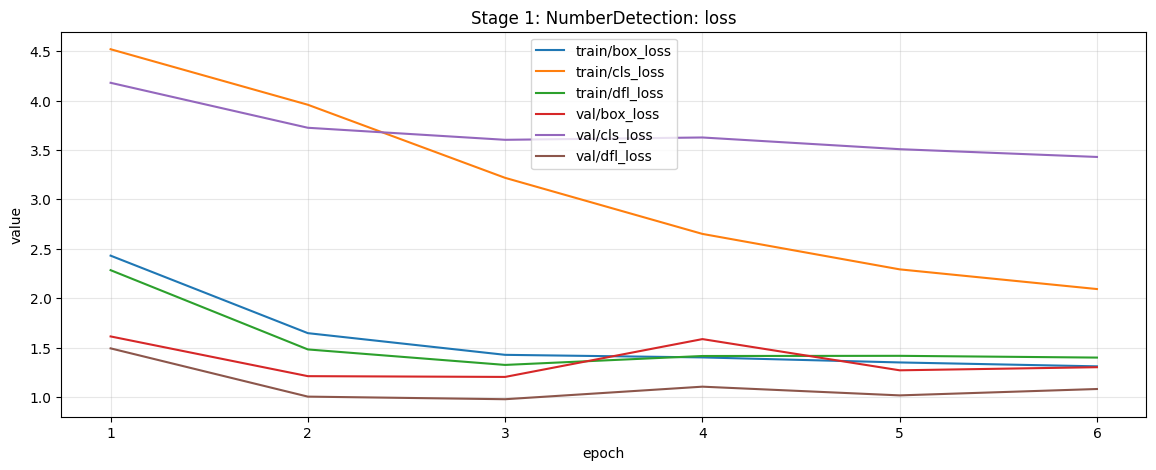

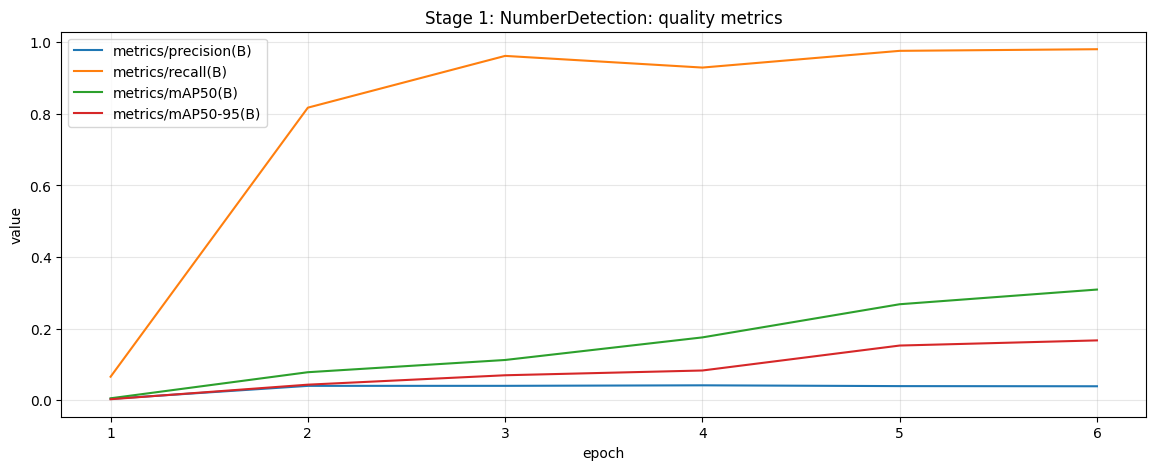

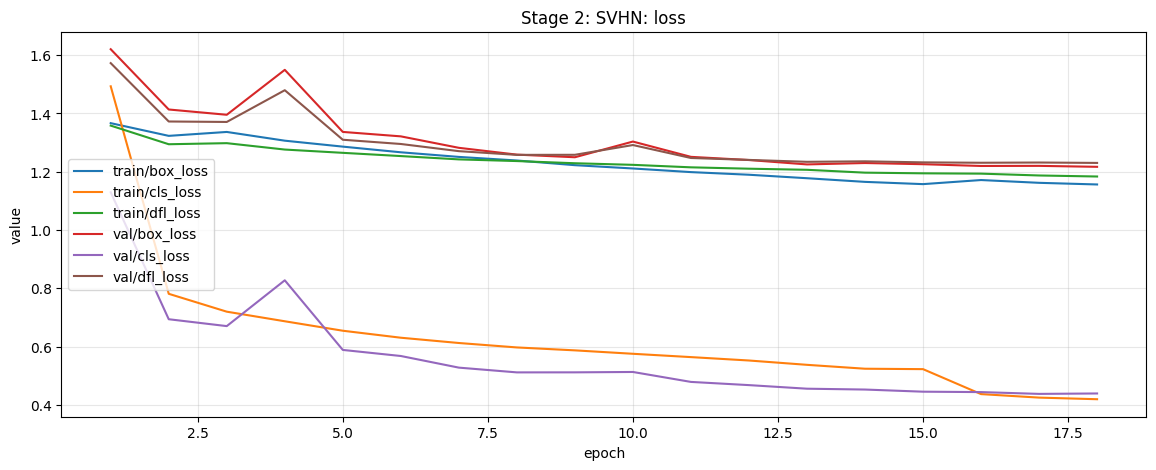

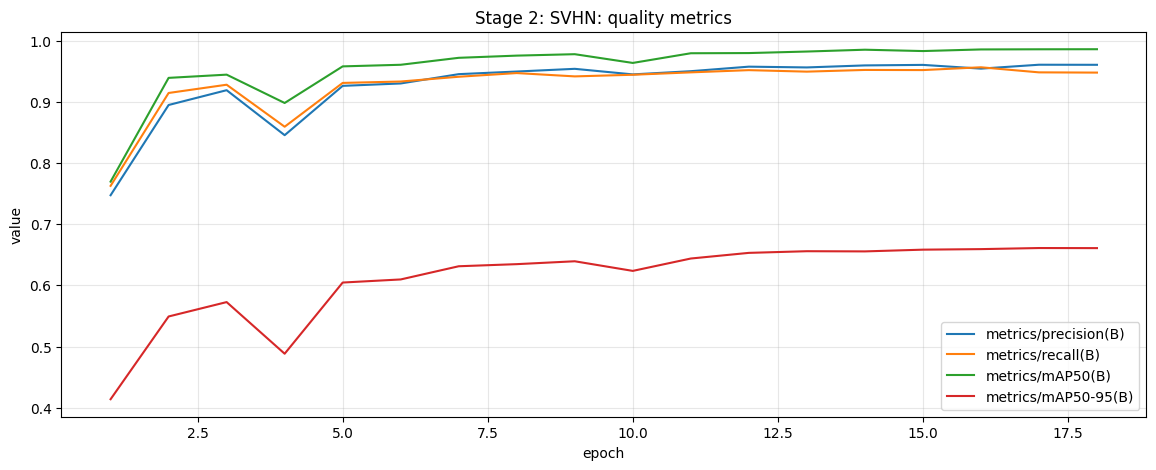

In [16]:
stage1_csv = CFG.runs_dir / "stage1_numberdetection" / "results.csv"
stage2_csv = CFG.runs_dir / "stage2_svhn_finetune" / "results.csv"

if stage1_csv.exists():
    plot_results_csv(stage1_csv, "Stage 1: NumberDetection")

plot_results_csv(stage2_csv, "Stage 2: SVHN")


## Оценка на тестовой части SVHN


In [44]:
def evaluate_svhn_test(
    best_model_path: Path,
    cfg: CFG,
    batch_size: int | None = None,
    max_images: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    model = YOLO(str(best_model_path))
    batch_size = batch_size or cfg.batch

    metrics = model.val(
        data=str(SVHN_YAML),
        split="test",
        imgsz=cfg.imgsz,
        batch=batch_size,
        device=cfg.device,
        conf=0.001,
        iou=0.6,
        plots=True,
        save_json=False,
        project=str(cfg.runs_dir),
        name="stage2_svhn_test_eval",
        exist_ok=True,
        verbose=False,
    )

    test_images_dir = cfg.processed_dir / "svhn_sequence" / "images" / "test"
    test_labels_dir = cfg.processed_dir / "svhn_sequence" / "labels" / "test"

    image_paths = sorted([p for p in test_images_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
    if max_images is not None:
        image_paths = image_paths[:max_images]

    rows = []
    tp = 0
    fp = 0
    fn = 0
    matched_ious = []

    for start in tqdm(range(0, len(image_paths), batch_size), desc="Custom IoU on SVHN test"):
        batch_paths = image_paths[start:start + batch_size]
        results = model.predict(
            source=[str(p) for p in batch_paths],
            imgsz=cfg.imgsz,
            conf=cfg.conf_eval,
            iou=0.6,
            device=cfg.device,
            verbose=False,
        )

        for src_path, result in zip(batch_paths, results):
            img_path = Path(src_path)
            orig_h, orig_w = result.orig_shape
            gt_label_path = test_labels_dir / f"{img_path.stem}.txt"

            gt_boxes = read_yolo_label(gt_label_path, orig_w, orig_h) if gt_label_path.exists() else []
            gt_box = gt_boxes[0][1:] if len(gt_boxes) else None

            pred_boxes = result.boxes.xyxy.cpu().numpy().tolist() if result.boxes is not None and len(result.boxes) else []
            pred_scores = result.boxes.conf.cpu().numpy().tolist() if result.boxes is not None and len(result.boxes) else []

            best_pred_box = None
            best_pred_score = None
            best_iou = 0.0

            if gt_box is not None and len(pred_boxes):
                ious = [box_iou_xyxy(gt_box, p) for p in pred_boxes]
                best_idx = int(np.argmax(ious))
                best_pred_box = pred_boxes[best_idx]
                best_pred_score = pred_scores[best_idx]
                best_iou = float(ious[best_idx])
            elif len(pred_boxes):
                best_pred_box = pred_boxes[0]
                best_pred_score = pred_scores[0]

            has_gt = gt_box is not None
            has_pred = best_pred_box is not None
            matched = has_gt and has_pred and best_iou >= cfg.iou_eval

            if matched:
                tp += 1
                matched_ious.append(best_iou)
            elif has_gt and has_pred:
                fp += 1
                fn += 1
            elif has_gt and not has_pred:
                fn += 1
            elif (not has_gt) and has_pred:
                fp += 1

            rows.append(
                {
                    "image": img_path.name,
                    "has_gt": has_gt,
                    "has_pred": has_pred,
                    "best_conf": float(best_pred_score) if best_pred_score is not None else 0.0,
                    "best_iou": best_iou,
                    "matched": matched,
                }
            )

    precision_custom = tp / max(1, tp + fp)
    recall_custom = tp / max(1, tp + fn)
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    summary = pd.DataFrame(
        [
            {
                "images_evaluated": len(image_paths),
                "precision_val_api": float(metrics.box.mp),
                "recall_val_api": float(metrics.box.mr),
                "mAP50": float(metrics.box.map50),
                "mAP50-95": float(metrics.box.map),
                "precision_custom@0.5IoU": precision_custom,
                "recall_custom@0.5IoU": recall_custom,
                "mean_iou_matched": mean_iou,
                "matched_samples": len(matched_ious),
            }
        ]
    )

    eval_dir = cfg.runs_dir / "stage2_svhn_test_eval"
    eval_dir.mkdir(parents=True, exist_ok=True)

    per_image = pd.DataFrame(rows).sort_values(["matched", "best_iou"], ascending=[True, True]).reset_index(drop=True)
    summary.to_csv(eval_dir / "summary_metrics.csv", index=False)
    per_image.to_csv(eval_dir / "per_image_metrics.csv", index=False)

    return summary, per_image


summary_metrics, per_image_metrics = evaluate_svhn_test(stage2_weights, CFG)
display(summary_metrics)


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32120MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1427.8±1863.3 MB/s, size: 17.1 KB)
val: Scanning /home/user/street_number_detector/data/processed/svhn_sequence/labels/test.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 6.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 8.8it/s 15.5s0.1s
                   all      13068      13068      0.897      0.884      0.923      0.542
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/user/street_number_detector/runs/stage2_svhn_test_eval


Custom IoU on SVHN test:   0%|          | 0/137 [00:00<?, ?it/s]

,images_evaluated,precision_val_api,recall_val_api,mAP50,mAP50-95,precision_custom@0.5IoU,recall_custom@0.5IoU,mean_iou_matched,matched_samples
0,13068,0.896634,0.884161,0.922654,0.541963,0.918182,0.896541,0.792309,11716


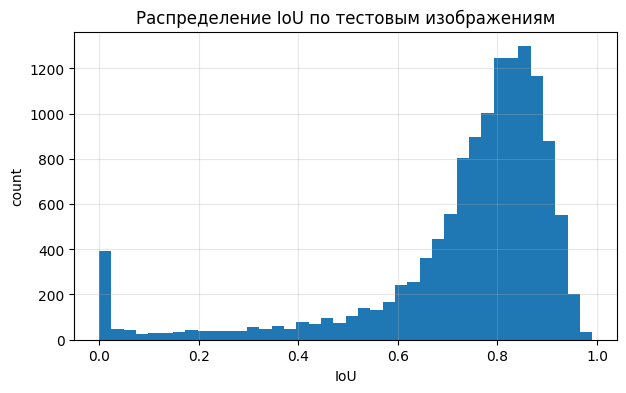

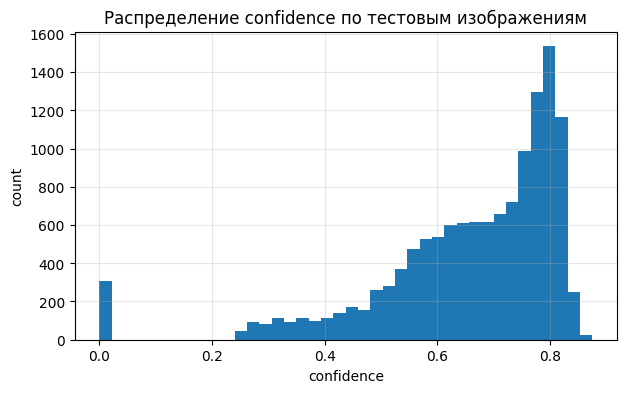

In [18]:
plt.figure(figsize=(7, 4))
plt.hist(per_image_metrics["best_iou"], bins=40)
plt.title("Распределение IoU по тестовым изображениям")
plt.xlabel("IoU")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(per_image_metrics["best_conf"], bins=40)
plt.title("Распределение confidence по тестовым изображениям")
plt.xlabel("confidence")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
def show_predictions_for_image_list(
    model_path: Path,
    image_paths: list[Path],
    labels_dir: Path | None = None,
    ncols: int = 3,
    figsize=(15, 10),
) -> None:
    if len(image_paths) == 0:
        print("Нет изображений для показа.")
        return

    model = YOLO(str(model_path))
    results = list(model.predict(source=[str(p) for p in image_paths], imgsz=CFG.imgsz, conf=CFG.conf_eval, verbose=False))

    n = len(results)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=figsize)

    for i, (src_path, result) in enumerate(zip(image_paths, results), start=1):
        img = load_rgb(src_path)
        vis = img.copy()

        if labels_dir is not None:
            h, w = img.shape[:2]
            gt_label_path = labels_dir / f"{Path(src_path).stem}.txt"
            gt_boxes = read_yolo_label(gt_label_path, w, h) if gt_label_path.exists() else []
            vis = draw_boxes(vis, gt_boxes, color=(0, 255, 0), lw=2)

        if result.boxes is not None and len(result.boxes) > 0:
            pred_boxes = result.boxes.xyxy.cpu().numpy().tolist()
            pred_scores = result.boxes.conf.cpu().numpy().tolist()
            for box, score in zip(pred_boxes, pred_scores):
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(
                    vis,
                    f"{score:.2f}",
                    (x1, max(10, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    1,
                    cv2.LINE_AA,
                )

        plt.subplot(nrows, ncols, i)
        plt.imshow(vis)
        plt.title(Path(src_path).name, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Лучшие примеры


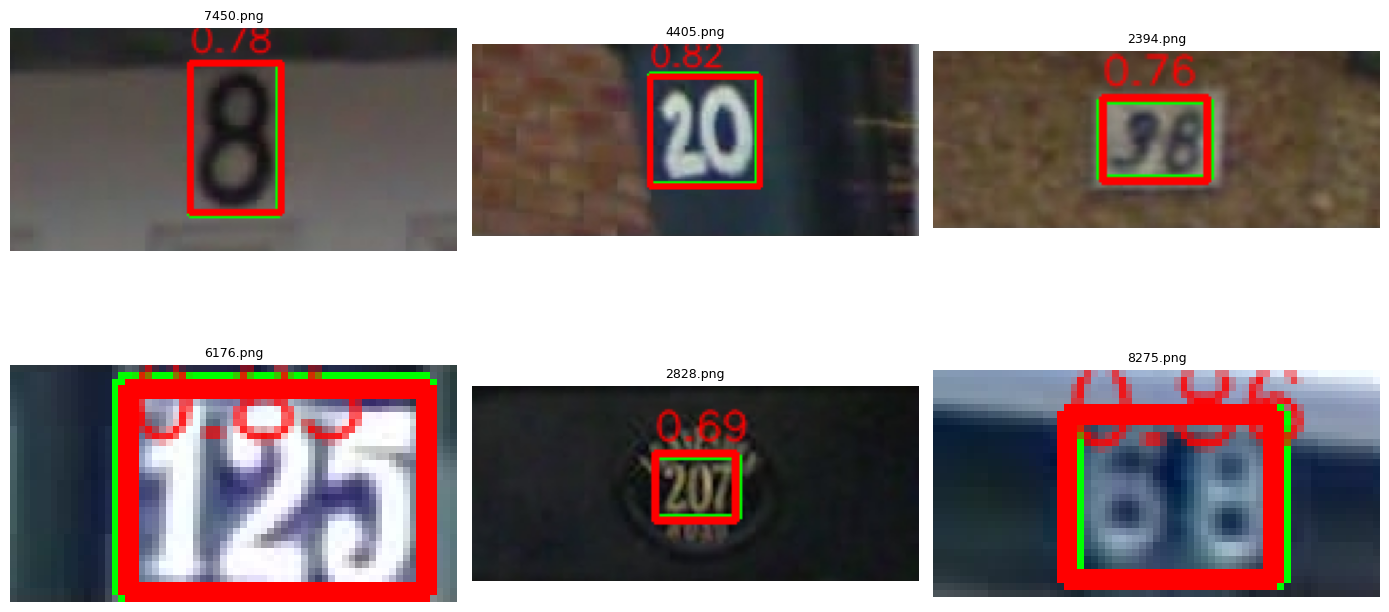

Самые трудные примеры


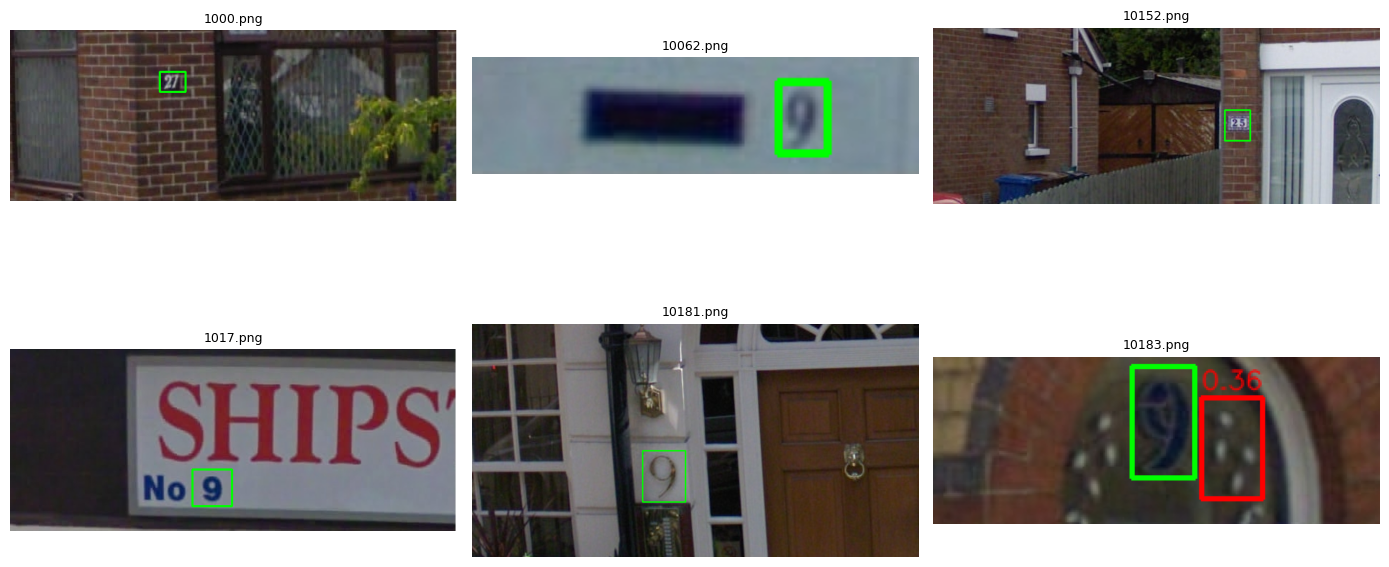

In [20]:
test_images_dir = CFG.processed_dir / "svhn_sequence" / "images" / "test"
test_labels_dir = CFG.processed_dir / "svhn_sequence" / "labels" / "test"

best_examples = per_image_metrics.sort_values("best_iou", ascending=False).head(6)["image"].tolist()
worst_examples = per_image_metrics.sort_values("best_iou", ascending=True).head(6)["image"].tolist()

print("Лучшие примеры")
show_predictions_for_image_list(
    stage2_weights,
    [test_images_dir / name for name in best_examples],
    labels_dir=test_labels_dir,
    ncols=3,
    figsize=(14, 8),
)

print("Самые трудные примеры")
show_predictions_for_image_list(
    stage2_weights,
    [test_images_dir / name for name in worst_examples],
    labels_dir=test_labels_dir,
    ncols=3,
    figsize=(14, 8),
)


## Сохранённые модели


In [21]:
saved_models = sorted(CFG.models_dir.glob("*.pt"))
pd.DataFrame({"model_path": [str(p) for p in saved_models]})


,model_path
0,/home/user/street_number_detector/models/stage...
1,/home/user/street_number_detector/models/stage...
2,/home/user/street_number_detector/models/stage...
3,/home/user/street_number_detector/models/stage...


## Инференс на ваших фотографиях

Положите 5–10 своих изображений в:

`street_number_detector/data/street_photos`

После этого запустите ячейки ниже.


In [29]:
def run_inference_dir(
    model_path: Path,
    source_dir: Path,
    out_dir: Path,
    imgsz: int = 640,
    conf: float = 0.25,
    device: int | str = 0,
) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    model = YOLO(str(model_path))

    results = list(
        model.predict(
            source=str(source_dir),
            imgsz=imgsz,
            conf=conf,
            device=device,
            save=True,
            project=str(out_dir.parent),
            name=out_dir.name,
            exist_ok=True,
            verbose=False,
        )
    )

    rows = []
    for result in results:
        path = Path(result.path)
        if result.boxes is None or len(result.boxes) == 0:
            rows.append(
                {
                    "image": path.name,
                    "detections": 0,
                    "top_conf": 0.0,
                    "x1": None,
                    "y1": None,
                    "x2": None,
                    "y2": None,
                }
            )
            continue

        boxes = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        best_idx = int(np.argmax(confs))
        x1, y1, x2, y2 = boxes[best_idx].tolist()

        rows.append(
            {
                "image": path.name,
                "detections": int(len(boxes)),
                "top_conf": float(confs[best_idx]),
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
            }
        )

    df = pd.DataFrame(rows).sort_values("image").reset_index(drop=True)
    df.to_csv(out_dir / "inference_summary.csv", index=False)
    return df


In [43]:
street_image_paths = sorted([p for p in CFG.street_photos_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])

if len(street_image_paths) == 0:
    print(f"Папка {CFG.street_photos_dir} пока пуста.")
else:
    street_results = run_inference_dir(
        model_path=stage2_weights,
        source_dir=CFG.street_photos_dir,
        out_dir=CFG.inference_dir / "street_photos_pred",
        imgsz=CFG.imgsz,
        conf=CFG.conf_eval,
        device=CFG.device,
    )
    display(street_results)


Results saved to /home/user/street_number_detector/inference/street_photos_pred


,image,detections,top_conf,x1,y1,x2,y2
0,photo_2026-03-12_18-02-39.jpg,4,0.451868,719.467163,789.860107,845.528687,912.412476
1,photo_2026-04-02_23-33-25.jpg,1,0.623776,85.368599,30.820578,114.116364,56.053207
2,photo_2026-04-02_23-34-57.jpg,1,0.777362,181.059402,123.503914,368.995453,221.937973
3,photo_2026-04-02_23-35-37.jpg,1,0.660301,201.257050,344.062317,294.843506,439.033936
4,photo_2026-04-02_23-36-24.jpg,1,0.399117,517.808411,733.781860,763.931213,853.688965
5,photo_2026-04-02_23-37-44.jpg,1,0.360720,251.681732,211.963135,367.731873,315.898193


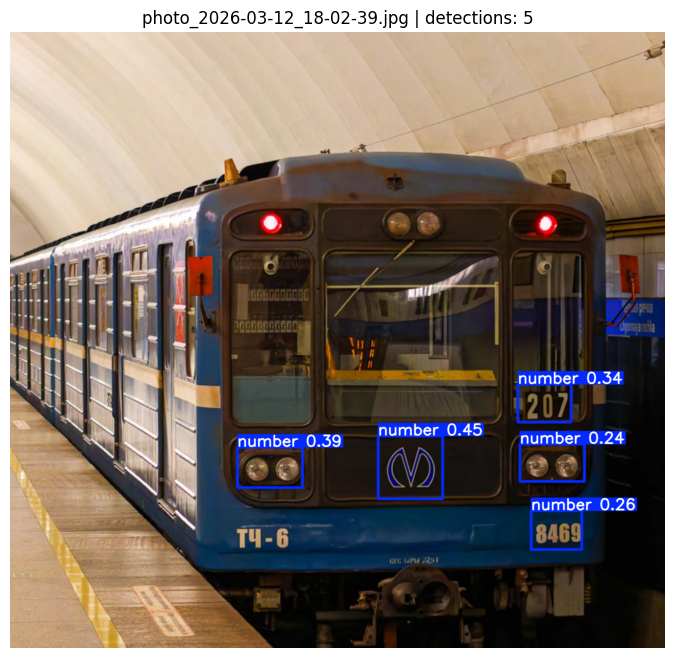

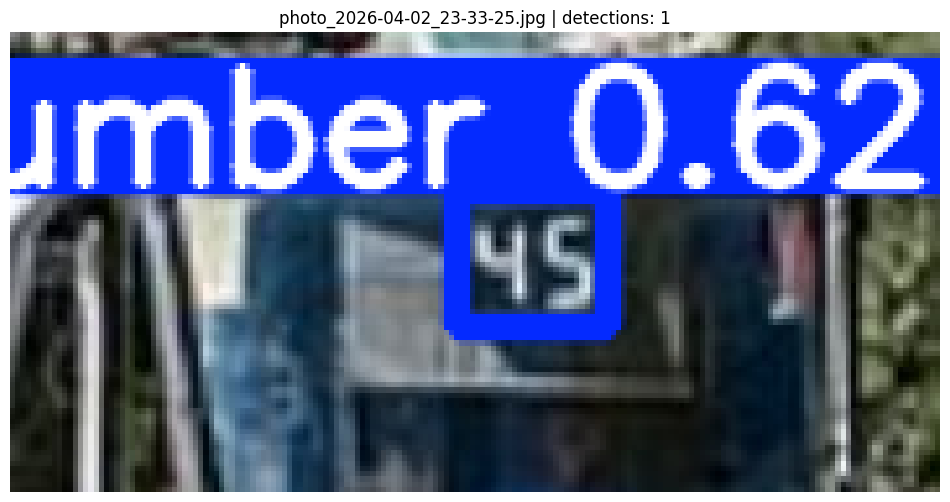

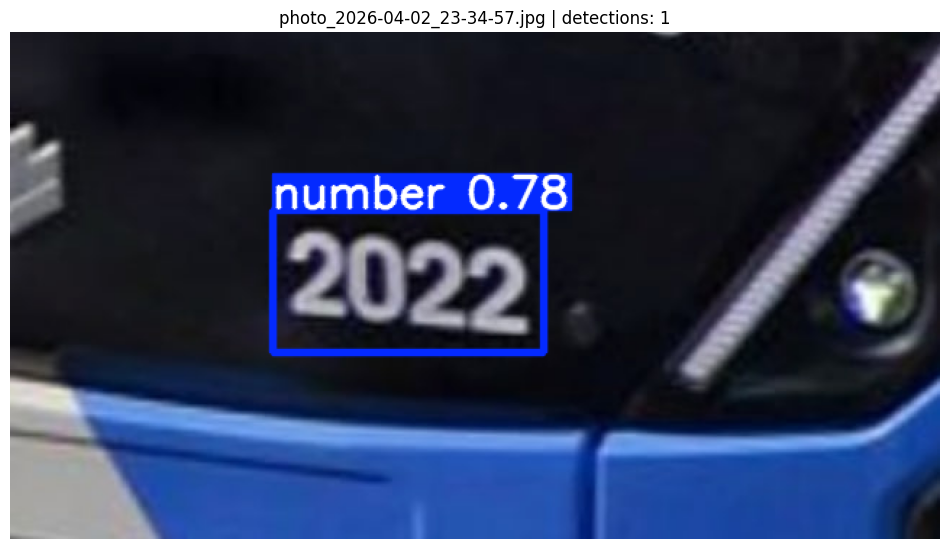

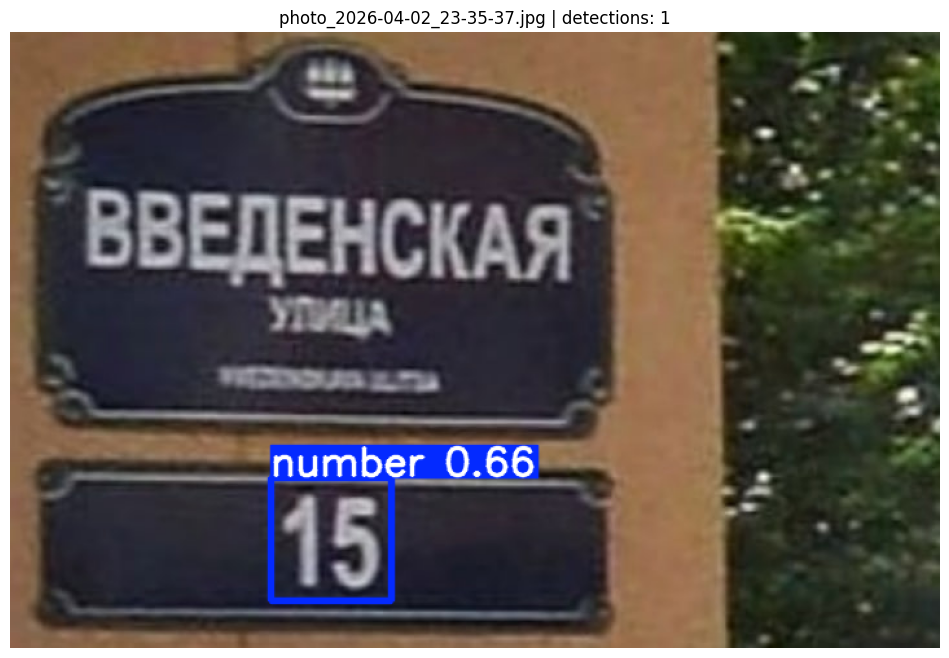

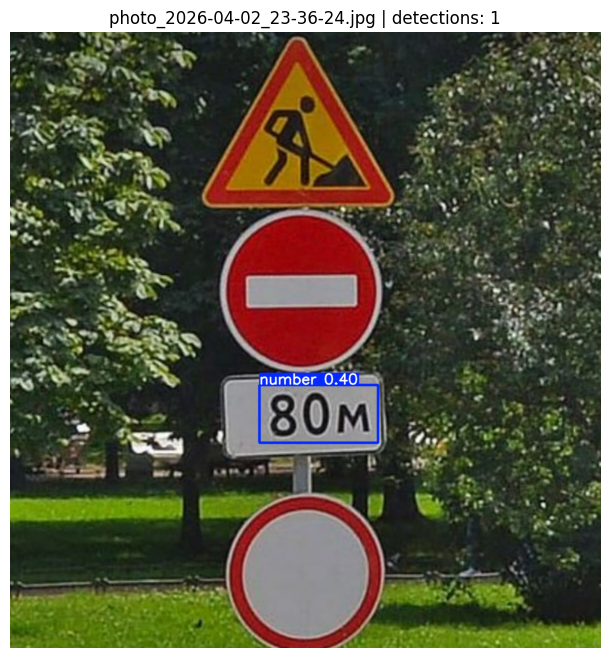

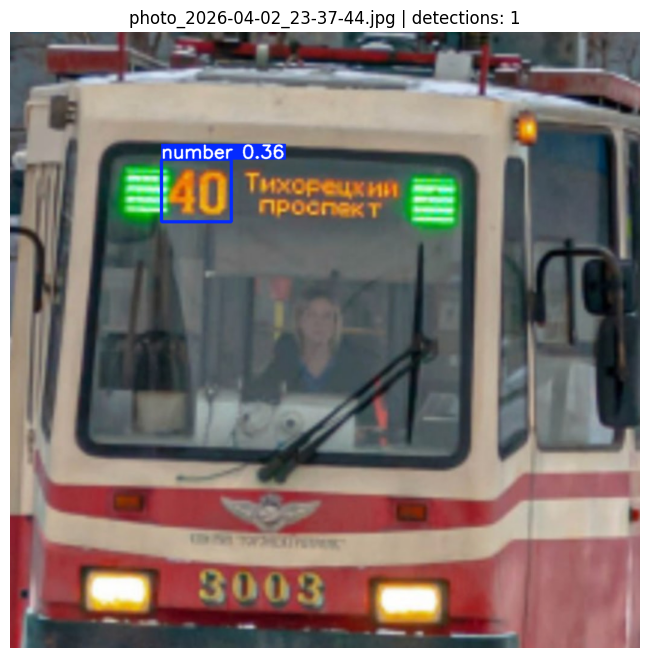

,image,det_id,conf,x1,y1,x2,y2,width,height
0,photo_2026-03-12_18-02-39.jpg,1,0.451868,719,789,845,912,126,123
1,photo_2026-03-12_18-02-39.jpg,2,0.394837,444,811,571,890,127,79
2,photo_2026-03-12_18-02-39.jpg,3,0.337705,992,688,1096,762,104,74
3,photo_2026-03-12_18-02-39.jpg,4,0.263905,1018,935,1117,1011,99,76
4,photo_2026-03-12_18-02-39.jpg,5,0.244303,996,805,1122,878,126,73
5,photo_2026-04-02_23-33-25.jpg,1,0.623776,85,30,114,56,29,26
6,photo_2026-04-02_23-34-57.jpg,1,0.777362,181,123,368,221,187,98
7,photo_2026-04-02_23-35-37.jpg,1,0.660301,201,344,294,439,93,95
8,photo_2026-04-02_23-36-24.jpg,1,0.399117,517,733,763,853,246,120
9,photo_2026-04-02_23-37-44.jpg,1,0.360720,251,211,367,315,116,104


Аннотированные изображения сохранены в: /home/user/street_number_detector/inference/street_photos_boxes


In [42]:
from pathlib import Path
import math
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

source_dir = CFG.street_photos_dir
save_dir = CFG.inference_dir / "street_photos_boxes"
save_dir.mkdir(parents=True, exist_ok=True)

image_paths = sorted([p for p in source_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])

model = YOLO(str(stage2_weights))

all_rows = []

for image_path in image_paths:
    results = model.predict(
        source=str(image_path),
        imgsz=CFG.imgsz,
        conf=0.20,
        iou=0.50,
        device=CFG.device,
        verbose=False
    )

    result = results[0]

    annotated_bgr = result.plot(line_width=3, font_size=18)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    out_path = save_dir / image_path.name
    cv2.imwrite(str(out_path), annotated_bgr)

    n_det = 0 if result.boxes is None else len(result.boxes)

    if result.boxes is not None and len(result.boxes) > 0:
        boxes_xyxy = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()

        for i, (box, conf) in enumerate(zip(boxes_xyxy, confs), start=1):
            x1, y1, x2, y2 = box.astype(int)
            all_rows.append({
                "image": image_path.name,
                "det_id": i,
                "conf": float(conf),
                "x1": int(x1),
                "y1": int(y1),
                "x2": int(x2),
                "y2": int(y2),
                "width": int(x2 - x1),
                "height": int(y2 - y1),
            })
    else:
        all_rows.append({
            "image": image_path.name,
            "det_id": 0,
            "conf": None,
            "x1": None,
            "y1": None,
            "x2": None,
            "y2": None,
            "width": None,
            "height": None,
        })

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_rgb)
    plt.title(f"{image_path.name} | detections: {n_det}")
    plt.axis("off")
    plt.show()

import pandas as pd
det_table = pd.DataFrame(all_rows)
display(det_table)

print(f"Аннотированные изображения сохранены в: {save_dir}")

## Что писать в выводе к работе

1. Была подготовлена задача детекции **полного номера целиком** в формате одного bounding box на номер.
2. В качестве базовой архитектуры использовался **YOLO11n**, дообученный на **SVHN Full Numbers**, а при наличии датасета **NumberDetection** — дополнительно предобученный на нём.
3. На тестовой части были получены метрики **Precision, Recall, mAP50, mAP50-95**, а также вручную посчитан **mean IoU**.
4. Модель показала, что даже компактный детектор может уверенно находить номера на изображениях, а дополнительное предобучение на более разнообразных сценах улучшает перенос на реальные фотографии города.
5. Инференс на собственных фотографиях подтвердил практическую применимость модели, хотя для ещё более устойчивой работы на реальных уличных сценах полезно расширять датасет примерами с разным масштабом, освещением, наклоном и фоном.
